# Tone (Formality) Analysis (xlmr_formality_classifier)

This notebook implements a tone analysis that quantifies **formality changes** introduced by AI humanization tools.

Humanization tools may alter formality levels by introducing either a more conversational or a more polished writing style compared to the original AI-generated content.

To measure formality, we use the **`xlmr_formality_classifier`**, a multilingual formality classification model based on **XLM-RoBERTa-base**, trained on the **XFORMAL** dataset. This dataset provides sentence-level annotations distinguishing formal and informal language across multiple languages.

### Methodology
1.  **Source of Truth**: The original essay (`datasets/essays/...` or `AI_essay` column).
2.  **Candidate Text**: The humanized essay (`datasets/humanized_essays/...` or `humanized_essay` column).
3.  **Process**:
    * **Step 1 (Sentence-Level Scoring)**: Each essay is segmented into individual sentences. The formality classifier assigns a scalar score in the range **[0, 1]** to each sentence, where lower values indicate a more informal tone and higher values indicate a more formal tone.
    * **Step 2 (Sentence Pairing)**: Sentences from the original and humanized essays are paired based on their original ordering.
    * **Step 3(Essay-Level Aggregation)**: The final formality change score for an essay pair is calculated as the **mean** of all sentence-level formality differences.

This score representes the overall degress of tone modification introduced by the humaniztion process.

In [1]:
import pandas as pd
import os

# Load the dataset
# Assuming datasets.csv is in the parent directory
dataset_path = '../datasets.csv'

if os.path.exists(dataset_path):
    df = pd.read_csv(dataset_path)
    print(f"Dataset loaded successfully. Shape: {df.shape}")
    display(df.head(3))
else:
    print(f"Error: {dataset_path} not found. Please check the path.")

Dataset loaded successfully. Shape: (180, 6)


,topic,length,AI_model,humanizer,AI_essay,humanized_essay
0,1,1,gemini2.5pro,AIHumanizer,The integration of social media into the lives...,The way social media has woven itself into the...
1,1,1,gemini2.5pro,Grammarly,The integration of social media into the lives...,Social media has become a big part of young pe...
2,1,1,gemini2.5pro,HumanizeAI,The integration of social media into the lives...,The penetration of social media into the lives...


In [24]:
import pandas as pd
import numpy as np
import re
import torch
import torch.nn.functional as F
from transformers import XLMRobertaTokenizerFast, XLMRobertaForSequenceClassification


In [18]:
# Take 1 essay pair
essay_pair = df.iloc[0]
ai_text = essay_pair['AI_essay']
human_text = essay_pair['humanized_essay']

print("AI chars:", len(ai_text))
print("Human chars:", len(human_text))

AI chars: 1873
Human chars: 1903


In [ ]:
# Function to split the essay into list of sentences
def split_into_sentences(text):
    sentences = re.split(r'(?<=[.!?])\s+(?=[A-Z"\(\[])', text)
    return [s.strip() for s in sentences if s.strip()]

# Split both essays into sentences
ai_sentences = split_into_sentences(ai_text)
human_sentences = split_into_sentences(human_text)

print("AI sentences:", len(ai_sentences))
print("Human sentences:", len(human_sentences))

AI sentences: 11
Human sentences: 13


In [25]:
MODEL_ID = "s-nlp/xlmr_formality_classifier"

tokenizer = XLMRobertaTokenizerFast.from_pretrained(MODEL_ID)
model = XLMRobertaForSequenceClassification.from_pretrained(MODEL_ID)

id2formality = {0: "formal", 1: "informal"}

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 1313.60it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]              
XLMRobertaForSequenceClassification LOAD REPORT from: s-nlp/xlmr_formality_classifier
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
# Make functions for reusability
def get_formality_scores(texts):
    encoding = tokenizer(
        texts,
        add_special_tokens=True,
        return_token_type_ids=True,
        truncation=True,
        padding="max_length",
        return_tensors="pt",
    )

    # inference
    output = model(**encoding)

    formality_scores = [
        {id2formality[idx]: score for idx, score in enumerate(text_scores.tolist())}
        for text_scores in output.logits.softmax(dim=1)
    ]
    return formality_scores

In [31]:
# Function to get the mean of overall formality and informality scores
def get_mean_formality_scores(formality_scores):
    formal_scores = [score['formal'] for score in formality_scores]
    informal_scores = [score['informal'] for score in formality_scores]
    mean_formal = np.mean(formal_scores)
    mean_informal = np.mean(informal_scores)
    return {'formal': mean_formal, 'informal': mean_informal}

In [32]:
ai_formality_scores = get_formality_scores(ai_sentences)
humanizes_formality_scores = get_formality_scores(human_sentences)
ai_mean_scores = get_mean_formality_scores(ai_formality_scores)
human_mean_scores = get_mean_formality_scores(humanizes_formality_scores)

print("AI essay mean formality scores:", ai_mean_scores)
print("Human essay mean formality scores:", human_mean_scores)

AI essay mean formality scores: {'formal': 0.9986178170550953, 'informal': 0.0013821970311586153}
Human essay mean formality scores: {'formal': 0.9964698965732868, 'informal': 0.003530087424083971}


In [35]:
ai_essays = df['AI_essay'].tolist()
humanized_essays = df['humanized_essay'].tolist()

print("Total ai essays processed:", len(ai_essays))
print("Total humanized essays processed:", len(humanized_essays))

Total ai essays processed: 180
Total humanized essays processed: 180


In [42]:
ai_essays_formality_scores = []
humanized_essays_formality_scores = []

for ai_text, humanized_text in zip(ai_essays, humanized_essays):
    ai_sentences = split_into_sentences(ai_text)
    humanized_sentences = split_into_sentences(humanized_text)
    
    ai_scores = get_formality_scores(ai_sentences)
    humanized_scores = get_formality_scores(humanized_sentences)
    
    ai_mean_scores = get_mean_formality_scores(ai_scores)
    humanized_mean_scores = get_mean_formality_scores(humanized_scores)
    
    ai_essays_formality_scores.append(ai_mean_scores)
    humanized_essays_formality_scores.append(humanized_mean_scores)

df['AI_formality_scores'] = ai_essays_formality_scores
df['humanized_formality_scores'] = humanized_essays_formality_scores
display(df[['AI_formality_scores', 'humanized_formality_scores']])

,AI_formality_scores,humanized_formality_scores
0,"{'formal': 0.9986178170550953, 'informal': 0.0...","{'formal': 0.9964698965732868, 'informal': 0.0..."
1,"{'formal': 0.9986178170550953, 'informal': 0.0...","{'formal': 0.9986342950300737, 'informal': 0.0..."
2,"{'formal': 0.9986178170550953, 'informal': 0.0...","{'formal': 0.9986209706826643, 'informal': 0.0..."
3,"{'formal': 0.9986178170550953, 'informal': 0.0...","{'formal': 0.9986198792854944, 'informal': 0.0..."
4,"{'formal': 0.9986178170550953, 'informal': 0.0...","{'formal': 0.9986308379606768, 'informal': 0.0..."
...,...,...
175,"{'formal': 0.9983048788879229, 'informal': 0.0...","{'formal': 0.9986264109611511, 'informal': 0.0..."
176,"{'formal': 0.9983048788879229, 'informal': 0.0...","{'formal': 0.9981897738244798, 'informal': 0.0..."
177,"{'formal': 0.9983048788879229, 'informal': 0.0...","{'formal': 0.9977880517641703, 'informal': 0.0..."
178,"{'formal': 0.9983048788879229, 'informal': 0.0...","{'formal': 0.9986353754997254, 'informal': 0.0..."


In [43]:
df.head()

,topic,length,AI_model,humanizer,AI_essay,humanized_essay,AI_formality_scores,humanized_formality_scores
0,1,1,gemini2.5pro,AIHumanizer,The integration of social media into the lives...,The way social media has woven itself into the...,"{'formal': 0.9986178170550953, 'informal': 0.0...","{'formal': 0.9964698965732868, 'informal': 0.0..."
1,1,1,gemini2.5pro,Grammarly,The integration of social media into the lives...,Social media has become a big part of young pe...,"{'formal': 0.9986178170550953, 'informal': 0.0...","{'formal': 0.9986342950300737, 'informal': 0.0..."
2,1,1,gemini2.5pro,HumanizeAI,The integration of social media into the lives...,The penetration of social media into the lives...,"{'formal': 0.9986178170550953, 'informal': 0.0...","{'formal': 0.9986209706826643, 'informal': 0.0..."
3,1,1,gemini2.5pro,Quillbot,The integration of social media into the lives...,Social media's introduction into young people'...,"{'formal': 0.9986178170550953, 'informal': 0.0...","{'formal': 0.9986198792854944, 'informal': 0.0..."
4,1,1,gemini2.5pro,UndetectableAI,The integration of social media into the lives...,Young people face a harmful environment throug...,"{'formal': 0.9986178170550953, 'informal': 0.0...","{'formal': 0.9986308379606768, 'informal': 0.0..."


In [ ]:
# extract P(formal) as scalar
df["AI_formality"] = df["AI_formality_scores"].apply(lambda x: x["formal"])
df["humanized_formality"] = df["humanized_formality_scores"].apply(lambda x: x["formal"])

# tone change
df["delta_formality"] = df["humanized_formality"] - df["AI_formality"]


In [61]:
df.head()

,topic,length,AI_model,humanizer,AI_essay,humanized_essay,AI_formality_scores,humanized_formality_scores,AI_formality,humanized_formality,delta_formality
0,1,1,gemini2.5pro,AIHumanizer,The integration of social media into the lives...,The way social media has woven itself into the...,"{'formal': 0.9986178170550953, 'informal': 0.0...","{'formal': 0.9964698965732868, 'informal': 0.0...",0.998618,0.996470,-0.002148
1,1,1,gemini2.5pro,Grammarly,The integration of social media into the lives...,Social media has become a big part of young pe...,"{'formal': 0.9986178170550953, 'informal': 0.0...","{'formal': 0.9986342950300737, 'informal': 0.0...",0.998618,0.998634,0.000016
2,1,1,gemini2.5pro,HumanizeAI,The integration of social media into the lives...,The penetration of social media into the lives...,"{'formal': 0.9986178170550953, 'informal': 0.0...","{'formal': 0.9986209706826643, 'informal': 0.0...",0.998618,0.998621,0.000003
3,1,1,gemini2.5pro,Quillbot,The integration of social media into the lives...,Social media's introduction into young people'...,"{'formal': 0.9986178170550953, 'informal': 0.0...","{'formal': 0.9986198792854944, 'informal': 0.0...",0.998618,0.998620,0.000002
4,1,1,gemini2.5pro,UndetectableAI,The integration of social media into the lives...,Young people face a harmful environment throug...,"{'formal': 0.9986178170550953, 'informal': 0.0...","{'formal': 0.9986308379606768, 'informal': 0.0...",0.998618,0.998631,0.000013


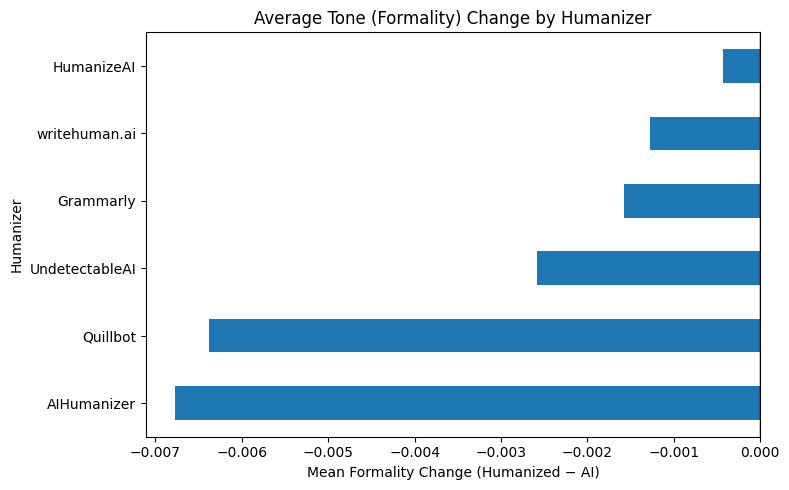

In [47]:
import matplotlib.pyplot as plt

mean_delta = (
    df.groupby("humanizer")["delta_formality"]
      .mean()
      .sort_values()
)

plt.figure(figsize=(8, 5))
mean_delta.plot(kind="barh")

plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Mean Formality Change (Humanized − AI)")
plt.ylabel("Humanizer")
plt.title("Average Tone (Formality) Change by Humanizer")

plt.tight_layout()
plt.show()


<Figure size 900x500 with 0 Axes>

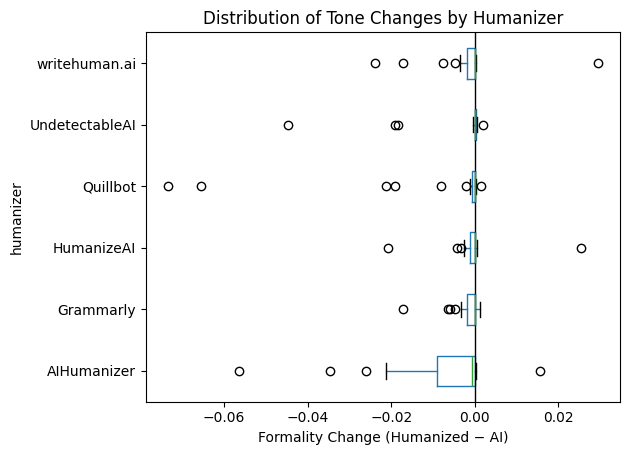

In [ ]:
plt.figure(figsize=(9, 5))

df.boxplot(
    column="delta_formality",
    by="humanizer",
    vert=False,
    grid=False
)

plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Formality Change (Humanized − AI)")
plt.title("Distribution of Tone Changes by Humanizer")
plt.suptitle("") 

plt.tight_layout()
plt.show()


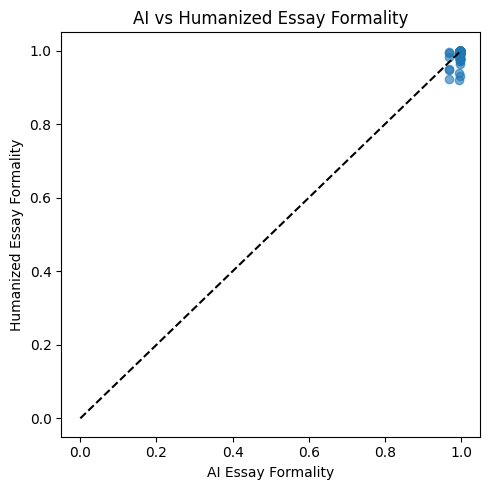

In [49]:
plt.figure(figsize=(5, 5))

plt.scatter(
    df["AI_formality"],
    df["humanized_formality"],
    alpha=0.6
)

plt.plot([0, 1], [0, 1], linestyle="--", color="black")
plt.xlabel("AI Essay Formality")
plt.ylabel("Humanized Essay Formality")
plt.title("AI vs Humanized Essay Formality")

plt.tight_layout()
plt.show()


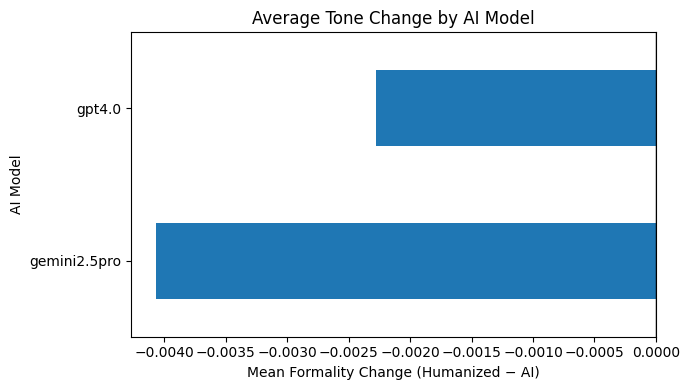

In [50]:
import matplotlib.pyplot as plt

mean_delta_ai = (
    df.groupby("AI_model")["delta_formality"]
      .mean()
      .sort_values()
)

plt.figure(figsize=(7, 4))
mean_delta_ai.plot(kind="barh")

plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Mean Formality Change (Humanized − AI)")
plt.ylabel("AI Model")
plt.title("Average Tone Change by AI Model")

plt.tight_layout()
plt.show()


<Figure size 800x400 with 0 Axes>

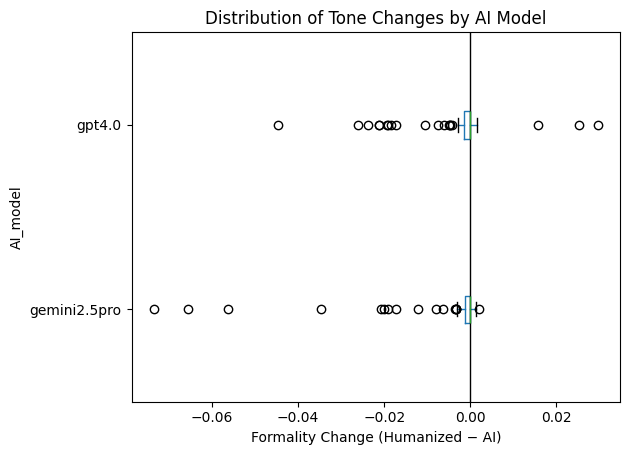

In [51]:
plt.figure(figsize=(8, 4))

df.boxplot(
    column="delta_formality",
    by="AI_model",
    vert=False,
    grid=False
)

plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Formality Change (Humanized − AI)")
plt.title("Distribution of Tone Changes by AI Model")
plt.suptitle("")

plt.tight_layout()
plt.show()


In [52]:
pivot = (
    df.groupby(["AI_model", "humanizer"])["delta_formality"]
      .mean()
      .unstack()
)
pivot


humanizer,AIHumanizer,Grammarly,HumanizeAI,Quillbot,UndetectableAI,writehuman.ai
AI_model,,,,,,
gemini2.5pro,-0.008800,-0.000979,-0.001995,-0.011158,0.000249,-0.001703
gpt4.0,-0.004739,-0.002179,0.001136,-0.001607,-0.005427,-0.000847


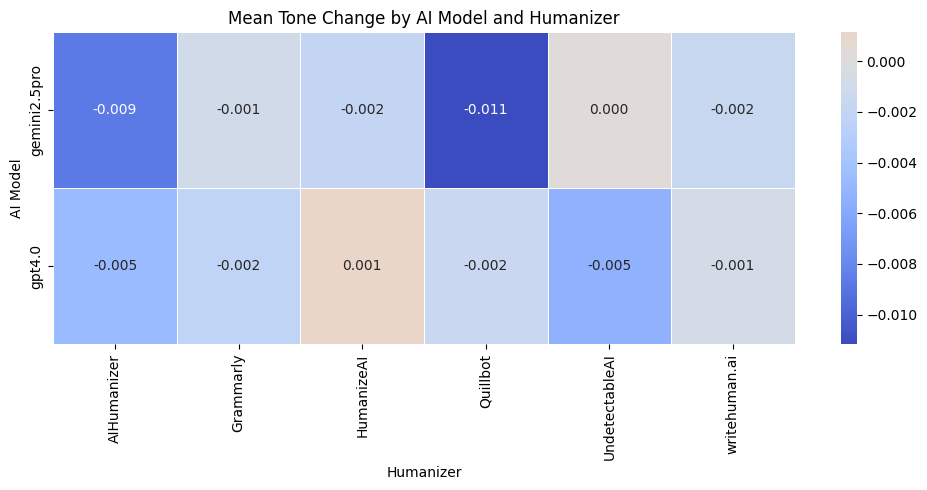

In [53]:
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.heatmap(
    pivot,
    annot=True,
    fmt=".3f",
    center=0,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Mean Tone Change by AI Model and Humanizer")
plt.xlabel("Humanizer")
plt.ylabel("AI Model")

plt.tight_layout()
plt.show()


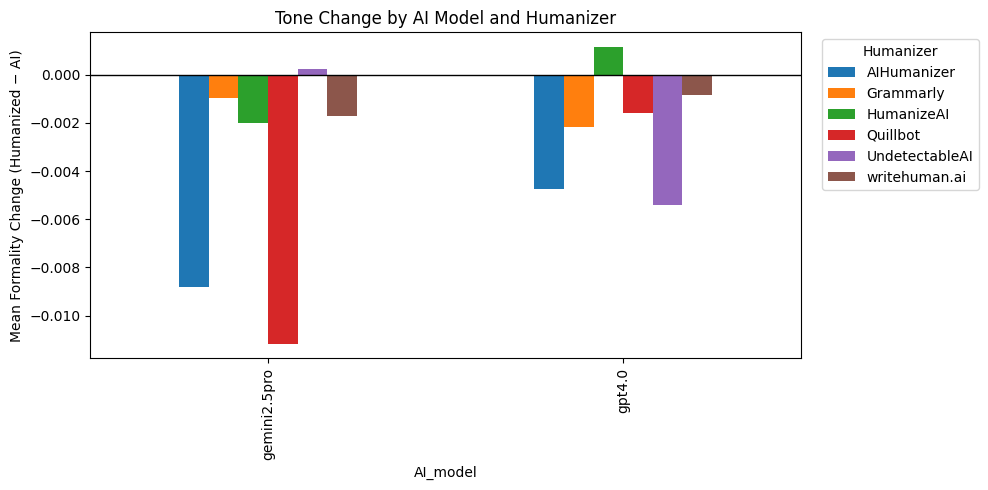

In [54]:
pivot.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.axhline(0, color="black", linewidth=1)
plt.ylabel("Mean Formality Change (Humanized − AI)")
plt.title("Tone Change by AI Model and Humanizer")
plt.legend(title="Humanizer", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()


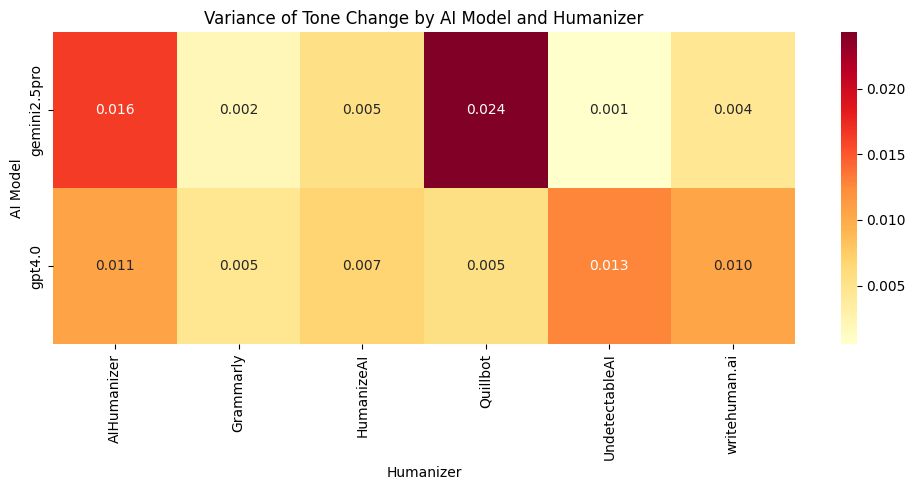

In [55]:
std_pivot = (
    df.groupby(["AI_model", "humanizer"])["delta_formality"]
      .std()
      .unstack()
)

plt.figure(figsize=(10, 5))
sns.heatmap(
    std_pivot,
    annot=True,
    fmt=".3f",
    cmap="YlOrRd"
)

plt.title("Variance of Tone Change by AI Model and Humanizer")
plt.xlabel("Humanizer")
plt.ylabel("AI Model")

plt.tight_layout()
plt.show()


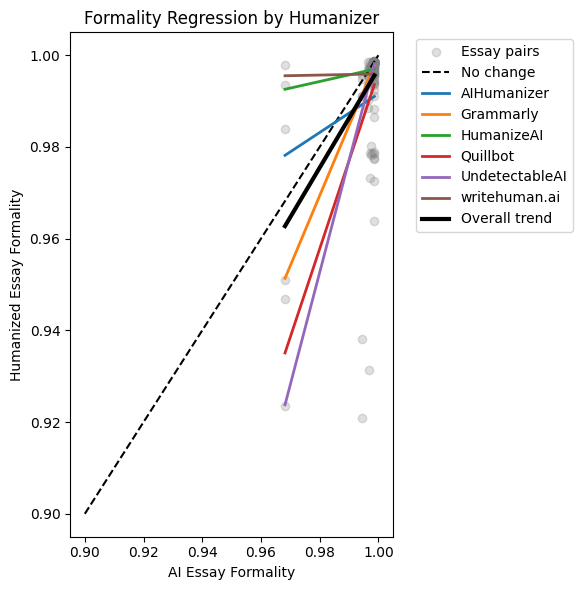

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))

# scatter points (all)
plt.scatter(
    df["AI_formality"],
    df["humanized_formality"],
    alpha=0.25,
    color="gray",
    label="Essay pairs"
)

# identity line
plt.plot([0.9, 1.0], [0.9, 1.0], linestyle="--", color="black", label="No change")

# regression per humanizer
for humanizer, sub in df.groupby("humanizer"):
    if len(sub) < 3:
        continue  # avoid unstable fits

    x = sub["AI_formality"].values
    y = sub["humanized_formality"].values

    coef = np.polyfit(x, y, 1)
    poly = np.poly1d(coef)

    xs = np.linspace(x.min(), x.max(), 100)
    plt.plot(xs, poly(xs), linewidth=2, label=humanizer)

# overall regression (bold)
x_all = df["AI_formality"].values
y_all = df["humanized_formality"].values
coef_all = np.polyfit(x_all, y_all, 1)
poly_all = np.poly1d(coef_all)

xs_all = np.linspace(x_all.min(), x_all.max(), 200)
plt.plot(xs_all, poly_all(xs_all), color="black", linewidth=3, label="Overall trend")

plt.xlabel("AI Essay Formality")
plt.ylabel("Humanized Essay Formality")
plt.title("Formality Regression by Humanizer")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()


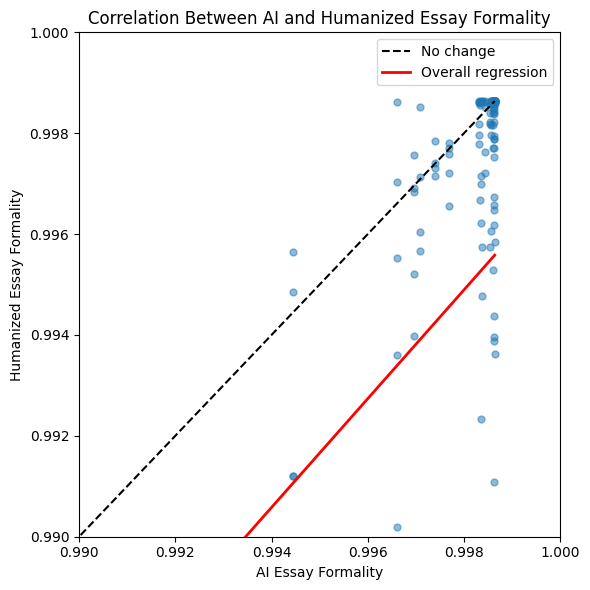

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x = df["AI_formality"].values
y = df["humanized_formality"].values

# regression
coef = np.polyfit(x, y, 1)
poly = np.poly1d(coef)

# smooth x-range for line
xs = np.linspace(x.min(), x.max(), 200)

plt.figure(figsize=(6, 6))

# scatter
plt.scatter(
    x, y,
    alpha=0.5,
    s=25
)

# identity line (no change)
plt.plot(
    [x.min(), x.max()],
    [x.min(), x.max()],
    linestyle="--",
    color="black",
    label="No change"
)

# regression line
plt.plot(
    xs,
    poly(xs),
    color="red",
    linewidth=2,
    label="Overall regression"
)

plt.xlabel("AI Essay Formality")
plt.ylabel("Humanized Essay Formality")
plt.title("Correlation Between AI and Humanized Essay Formality")
plt.legend()

# zoom to reveal structure
plt.xlim(0.99, 1.0)
plt.ylim(0.99, 1.0)

plt.tight_layout()
plt.show()


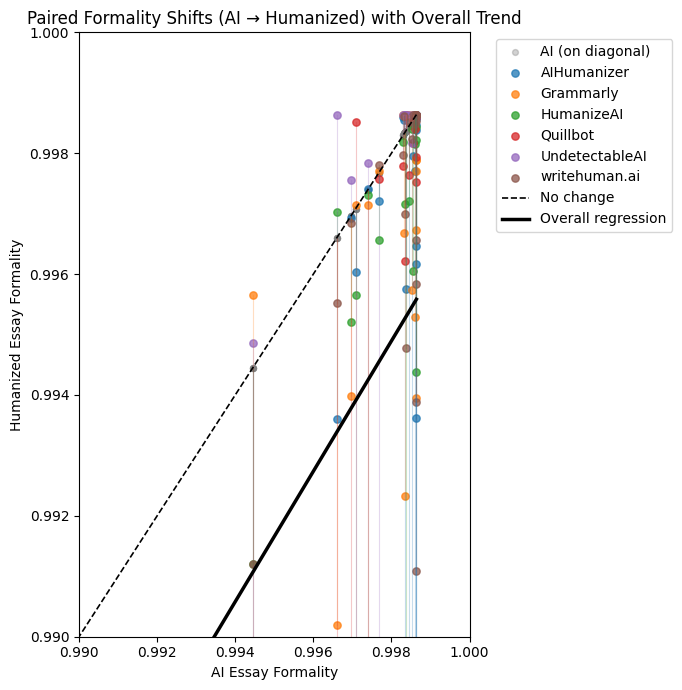

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x = df["AI_formality"].to_numpy()
y = df["humanized_formality"].to_numpy()
h = df["humanizer"].astype(str).to_numpy()

# overall regression on (x, y)
coef = np.polyfit(x, y, 1)
poly = np.poly1d(coef)
xs = np.linspace(x.min(), x.max(), 200)

# humanizer -> color mapping (matplotlib default cycle)
humanizers = sorted(df["humanizer"].unique())
cmap = plt.get_cmap("tab10")
color_map = {hz: cmap(i % 10) for i, hz in enumerate(humanizers)}

plt.figure(figsize=(7, 7))

# 1) draw subtle connecting lines (AI point on diagonal -> humanized point)
for xi, yi, hz in zip(x, y, h):
    plt.plot([xi, xi], [xi, yi], alpha=0.25, linewidth=0.8, color=color_map[hz])

# 2) plot AI points (on diagonal) in light gray
plt.scatter(x, x, s=18, alpha=0.35, color="gray", label="AI (on diagonal)")

# 3) plot humanized points colored by humanizer
for hz in humanizers:
    mask = (df["humanizer"] == hz).to_numpy()
    plt.scatter(
        x[mask], y[mask],
        s=28, alpha=0.75,
        color=color_map[hz],
        label=hz
    )

# 4) diagonal line (no change)
plt.plot([x.min(), x.max()], [x.min(), x.max()],
         linestyle="--", color="black", linewidth=1.2, label="No change")

# 5) overall regression line
plt.plot(xs, poly(xs), color="black", linewidth=2.5, label="Overall regression")

plt.xlabel("AI Essay Formality")
plt.ylabel("Humanized Essay Formality")
plt.title("Paired Formality Shifts (AI → Humanized) with Overall Trend")

# Zoom in because scores are near 1.0 (this makes the plot readable)
plt.xlim(0.99, 1.0)
plt.ylim(0.99, 1.0)

plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()
